In [1]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay

In [ ]:
df = pd.read_csv('gemini.csv')
df

In [3]:
y = df['З/П']
X = df.drop(['З/П'], axis = 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [4]:
model = CatBoostClassifier(
    iterations=500,           # для маленьких данных лучше меньше итераций + раннее стоппинг
    learning_rate=0.03,
    depth=6,
    auto_class_weights='Balanced', # Решает проблему дисбаланса 0 и 1
    eval_metric='F1',          # Оптимизируем под дисбаланс, а не под точность
    verbose=100,               # Выводить лог каждые 100 шагов
    random_seed=42
)

# 3. Обучение с защитой от переобучения
model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50   # Остановится, если F1 перестанет расти
)

# 4. Получение вероятностей
y_proba = model.predict_proba(X_test)[:, 1]

# 5. Предсказание классов
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

0:	learn: 0.9743590	test: 0.4615385	best: 0.4615385 (0)	total: 91.5ms	remaining: 45.6s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8888888889
bestIteration = 3

Shrink model to first 4 iterations.
              precision    recall  f1-score   support

         0.0       0.80      1.00      0.89         8
         1.0       1.00      0.80      0.89        10

    accuracy                           0.89        18
   macro avg       0.90      0.90      0.89        18
weighted avg       0.91      0.89      0.89        18



In [5]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 88.89%


Accuracy:0.889
Precision:1.000
Recall:  0.800
F1-score: 0.889

Confusion Matrix:
 [[8 0]
 [2 8]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.80      1.00      0.89         8
         1.0       1.00      0.80      0.89        10

    accuracy                           0.89        18
   macro avg       0.90      0.90      0.89        18
weighted avg       0.91      0.89      0.89        18

0:	learn: 1.0000000	total: 948us	remaining: 473ms
100:	learn: 1.0000000	total: 62ms	remaining: 245ms
200:	learn: 1.0000000	total: 119ms	remaining: 177ms
300:	learn: 1.0000000	total: 167ms	remaining: 110ms
400:	learn: 1.0000000	total: 218ms	remaining: 53.8ms
499:	learn: 1.0000000	total: 264ms	remaining: 0us
0:	learn: 1.0000000	total: 792us	remaining: 395ms
100:	learn: 1.0000000	total: 55.7ms	remaining: 220ms
200:	learn: 1.0000000	total: 113ms	remaining: 167ms
300:	learn: 1.0000000	total: 169ms	remaining: 112ms
400:	learn: 1.0000000	total: 234ms	r

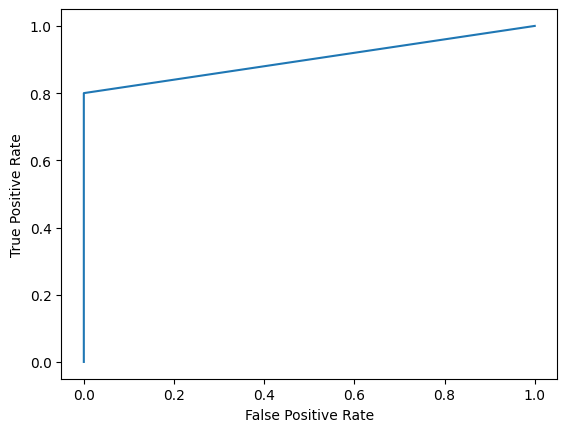

In [6]:
def metrix(prediction,clf, X_test):
    from sklearn.model_selection import cross_val_score
    accuracy_score(prediction, y_test)
    print(f"Accuracy:{accuracy_score(y_test, prediction):.3f}")
    print(f"Precision:{precision_score(y_test, prediction):.3f}")
    print(f"Recall:  {recall_score(y_test, prediction):.3f}")
    print(f"F1-score: {f1_score(y_test, prediction):.3f}")
    # print(f"ROC-AUC:{roc_auc_score(y_test, y_proba):.3f}")
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, prediction))
    print("\nClassification Report:\n", classification_report(y_test, prediction))


    scores_f1 = cross_val_score(clf, X_test, y_test, cv=5, scoring='f1')

    print(f"F1-результаты по фолдам: {scores_f1}")
    print(f"Средний F1: {scores_f1.mean():.2f}")
    from sklearn import metrics
    fpr, tpr, _ = metrics.roc_curve(y_test,  prediction)

    # построение ROC кривой
    plt.plot(fpr, tpr)
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()
    return
metrix(y_pred, model, X_test)

In [13]:
print(f"Accuracy:{accuracy_score(y_test, y_pred):.3f}")
print(f"Precision:{precision_score(y_test, y_pred):.3f}")
print(f"Recall:  {recall_score(y_test, y_pred):.3f}")
print(f"F1-score: {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC:{roc_auc_score(y_test, y_proba):.3f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy:1.000
Precision:1.000
Recall:  1.000
F1-score: 1.000
ROC-AUC:1.000

Confusion Matrix:
 [[5 0]
 [0 8]]

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         5
         1.0       1.00      1.00      1.00         8

    accuracy                           1.00        13
   macro avg       1.00      1.00      1.00        13
weighted avg       1.00      1.00      1.00        13



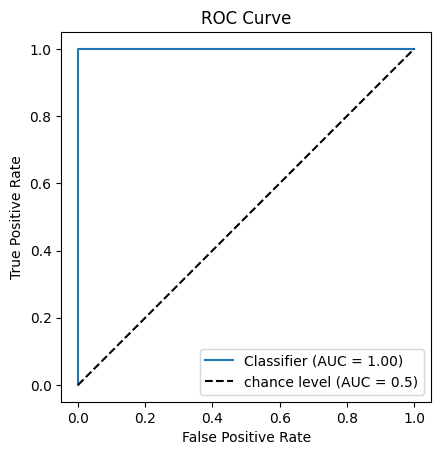

In [14]:
RocCurveDisplay.from_predictions(y_test, y_proba)

plt.plot([0, 1], [0, 1], "k--", label="chance level (AUC = 0.5)") 
plt.axis("square")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

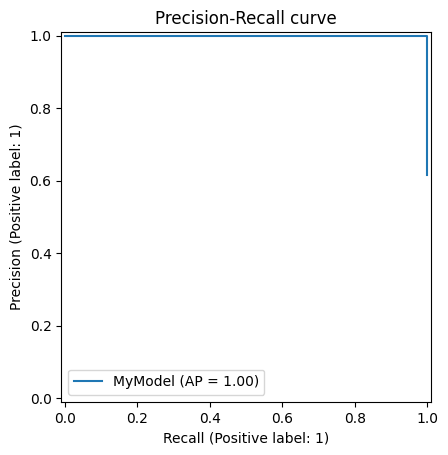

In [15]:
display = PrecisionRecallDisplay.from_predictions(y_test, y_proba, name="MyModel")

_ = display.ax_.set_title("Precision-Recall curve")
plt.show()